In [1]:
import torch
import lightning
import logging
import cocodeel.dataset
import cocodeel.model
import cocodeel.posthoc_model

In [2]:
# Set default dtype, device and seed.
torch.set_default_dtype(torch.float)
torch.set_default_device("cpu")
torch.manual_seed(0)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

In [3]:
N = 10000
# Create data.
X = torch.cat((torch.ones(N, 1), torch.randn(N, 2)), 1)
# U ~ X * delta + N(0,1)
U = torch.matmul(X[:,1:], torch.ones(2, 32)) + torch.randn(N, 32)
# y ~ X * beta + U * gamma + N(0,1)
y = (torch.matmul(X, torch.tensor([1., 1., 1.])) + torch.matmul(U, torch.ones(32)) + torch.randn(N))
# Create training and validation data.
train_data = cocodeel.dataset.CovarDataset(U, X, y)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=True)

## 1. Neural Network with Covariates

In [4]:
# Backbone.
class Backbone(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(in_features, 2*in_features),
            torch.nn.ReLU(),
            torch.nn.Linear(2*in_features, 2*in_features),
            torch.nn.ReLU(),
            torch.nn.Linear(2*in_features, out_features)
        )
        
    def forward(self, x):
        return self.model(x)

# Model parameters. 
params = {
    "backbone": Backbone,
    "output_func": torch.nn.Identity,
    "loss_func": torch.nn.MSELoss,
    "optimizer": torch.optim.AdamW,
    "num_features": 32,
    "num_covars": 3,
    "backbone_params": {"in_features": 32, "out_features": 32},
    "optimizer_params": {"lr": 0.01}
}

In [5]:
# Train model.
net = cocodeel.model.CovarNeuralNetwork(**params)
trainer = lightning.Trainer(max_epochs=10, enable_progress_bar=False)
trainer.fit(net, train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Manuel Pfeuffer\anaconda3\envs\cocodeel\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
C:\Users\Manuel Pfeuffer\anaconda3\envs\cocodeel\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type     | Params | Mode 
------------------------------------------------------
0 | backbone         | Backb

## 2. Post-hoc Orthogoanlized Neural Network

In [6]:
# Train PHO model.
pho = cocodeel.posthoc_model.PostHocOrthogonalizedModel(net, train_loader)

## 3. Re-estimating last layer using least squares (LS)

In [7]:
# Train IWLS model.
phls = cocodeel.posthoc_model.PostHocLSModel(net, train_loader)
phols = cocodeel.posthoc_model.PostHocLSModel(net, train_loader, orthogonalize=True)

## Comparison of Models

In [8]:
# Compare coefficients of the three models.
print("Original model:")
print(net.struct_predictor.weight)
print("Post-hoc orthogonalized model:")
print(pho.model.struct_predictor.weight)
print("Post-hoc LS model:")
print(phls.model.struct_predictor.weight)
print("Post-hoc orthogonalized LS model:")
print(phols.model.struct_predictor.weight)

Original model:
Parameter containing:
tensor([[0.2030, 0.1159, 0.4140]], requires_grad=True)
Post-hoc orthogonalized model:
Parameter containing:
tensor([[ 1.0159, 32.5962, 32.9086]], requires_grad=True)
Post-hoc LS model:
Parameter containing:
tensor([[0.0999, 0.9364, 0.9503]])
Post-hoc orthogonalized LS model:
Parameter containing:
tensor([[ 0.8843, 32.9759, 33.0070]])


In [9]:
# Comparison of performance on test data.
N = 10000
U = torch.randn(N, 32)
X = torch.matmul(U, torch.ones(32, 2)) + torch.randn(N, 2)
X = torch.cat((torch.ones(N, 1), X), 1)
y = (torch.matmul(X, torch.tensor([1., 1., 1.])) + torch.matmul(U, torch.ones(32)) + torch.randn(N))
mse = torch.nn.MSELoss()
print("Original model:", mse(net(U, X).squeeze(), y).item())
print("Post-hoc orthogonalized model:", mse(pho(U, X).squeeze(), y).item())
print("Post-hoc LS model:", mse(phls(U, X).squeeze(), y).item())
print("Post-hoc orthogonalized LS model:", mse(phols(U, X).squeeze(), y).item())

Original model: 72.44286346435547
Post-hoc orthogonalized model: 72.44305419921875
Post-hoc LS model: 1.6098030805587769
Post-hoc orthogonalized LS model: 1.6163644790649414


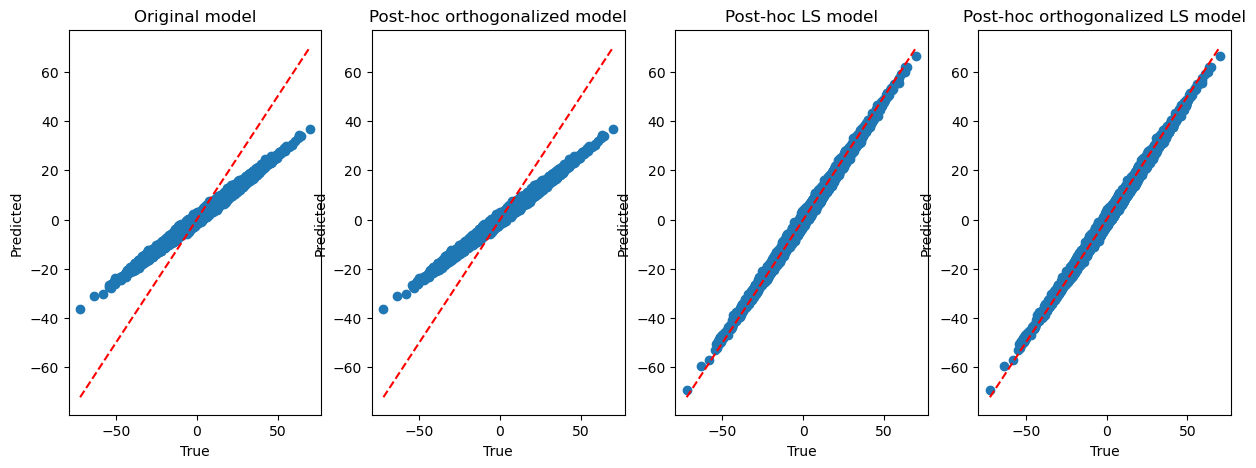

In [10]:
# Residualplot of all models with same plot limits.
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.scatter(y, net(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Original model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.subplot(1, 4, 2)
plt.scatter(y, pho(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Post-hoc orthogonalized model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.subplot(1, 4, 3)
plt.scatter(y, phls(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Post-hoc LS model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.subplot(1, 4, 4)
plt.scatter(y, phols(U, X).detach().numpy())
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.title("Post-hoc orthogonalized LS model")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()